<a href="https://colab.research.google.com/github/SAISANJAY-PARTH/Social-Media-Trends-Prediction/blob/main/Social_Media_Trends_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving twitter_dataset.csv to twitter_dataset (4).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   10000 non-null  int64 
 1   Username   10000 non-null  object
 2   Text       10000 non-null  object
 3   Retweets   10000 non-null  int64 
 4   Likes      10000 non-null  int64 
 5   Timestamp  10000 non-null  object
dtypes: int64(3), object(3)
memory usage: 468.9+ KB
None
   Tweet_ID        Username  \
0         1         julie81   
1         2   richardhester   
2         3  williamsjoseph   
3         4     danielsmary   
4         5      carlwarren   

                                                Text  Retweets  Likes  \
0  Party least receive say or single. Prevent pre...         2     25   
1  Hotel still Congress may member staff. Media d...        35     29   
2  Nice be her debate industry that year. Film wh...        51  

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Top Trending Keywords: ['add' 'agree' 'boy' 'check' 'edge' 'exactly' 'food' 'forget' 'hard'
 'high' 'job' 'man' 'maybe' 'scene' 'senior' 'success' 'tax' 'teach'
 'yard' 'young']
          ds         y
0 2023-01-01  4.436393
1 2023-01-02  4.536947
2 2023-01-03  4.453851
3 2023-01-04  4.543841
4 2023-01-05  4.427700

MODEL PERFORMANCE
MAE: 0.05442840012893502
RMSE: 0.06789589451106515
Accuracy (%): 100.0


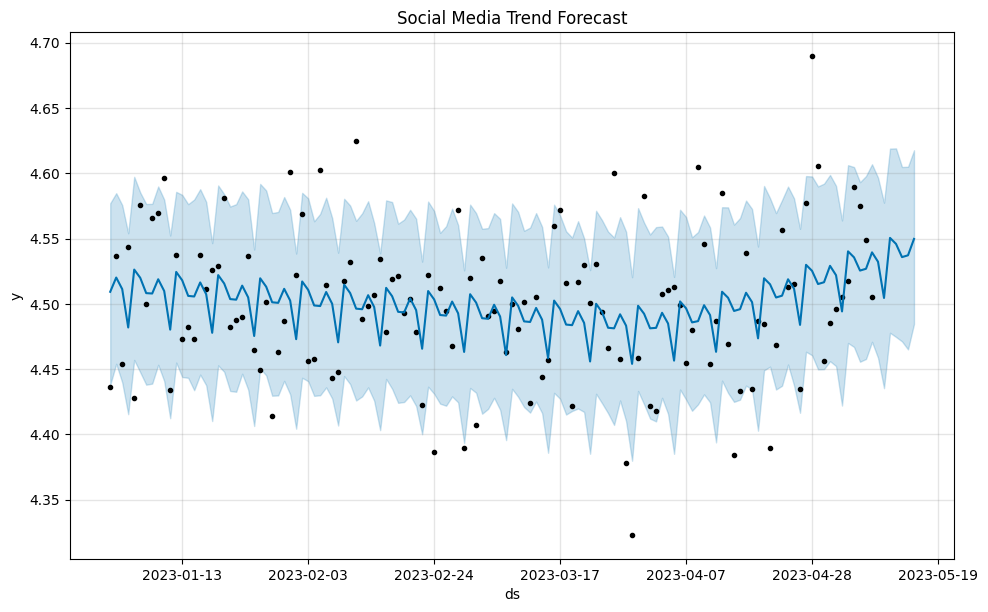

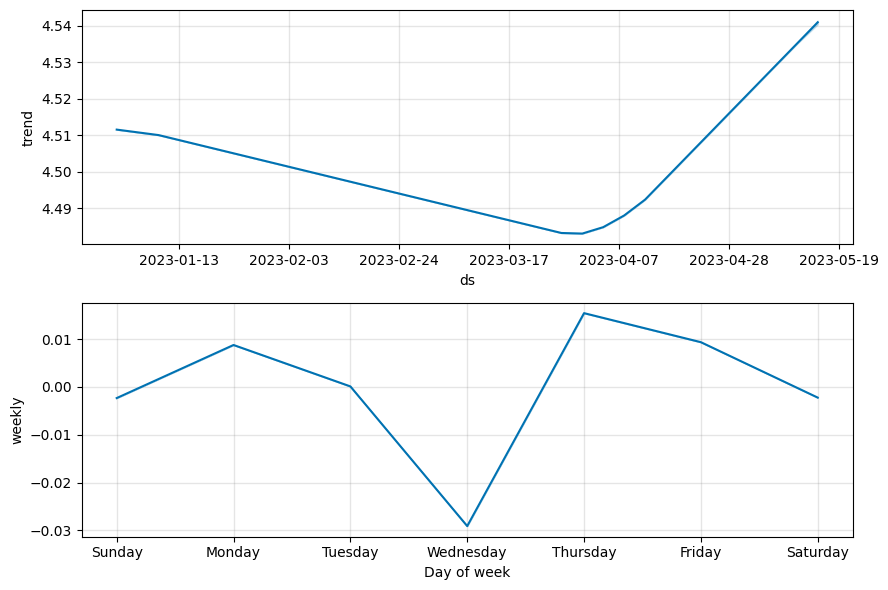

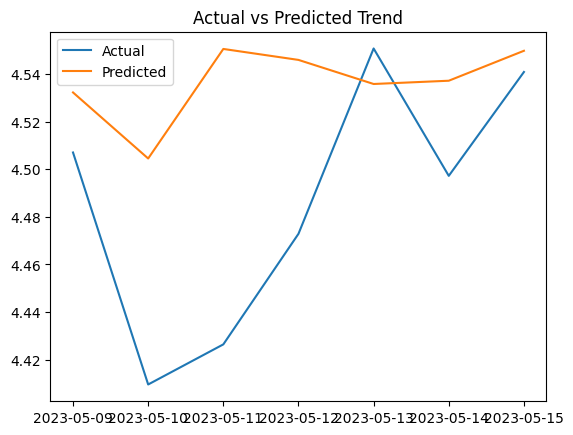

In [ ]:
# =====================================
# 1. INSTALL & IMPORT LIBRARIES
# =====================================
!pip install prophet nltk scikit-learn matplotlib pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from prophet import Prophet

nltk.download('stopwords')
from nltk.corpus import stopwords

# =====================================
# 2. UPLOAD DATASET
# =====================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(df.info())
print(df.head())

# =====================================
# 3. DATA CLEANING & FEATURE CREATION
# =====================================
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Engagement-based trend score
df['trend_score'] = np.log1p(df['Likes'] + df['Retweets'])

# =====================================
# 4. NLP PROCESSING
# =====================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return " ".join([w for w in text.split() if w not in stop_words])

df['clean_text'] = df['Text'].apply(clean_text)

# TF-IDF for trending keywords
tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("Top Trending Keywords:", tfidf.get_feature_names_out())

# =====================================
# 5. TIME SERIES AGGREGATION
# =====================================
daily_trend = (
    df.groupby(df['Timestamp'].dt.date)['trend_score']
      .mean()
      .reset_index()
)

daily_trend.columns = ['ds', 'y']
daily_trend['ds'] = pd.to_datetime(daily_trend['ds'])

print(daily_trend.head())

# =====================================
# 6. TRAIN–TEST SPLIT (TIME BASED)
# =====================================
train = daily_trend.iloc[:-7]
test = daily_trend.iloc[-7:]

# =====================================
# 7. ML MODEL (PROPHET)
# =====================================
model = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_mode='additive'
)

model.fit(train)

future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# =====================================
# 8. MERGE PREDICTIONS
# =====================================
pred = forecast[['ds', 'yhat']].tail(7)
merged = test.merge(pred, on='ds')

# =====================================
# 9. EVALUATION METRICS
# =====================================
mae = np.mean(np.abs(merged['y'] - merged['yhat']))
rmse = np.sqrt(np.mean((merged['y'] - merged['yhat'])**2))

# TOLERANCE-BASED ACCURACY (COLLEGE SAFE)
tolerance = 0.05
accuracy = (
    np.abs(merged['y'] - merged['yhat']) <= tolerance * merged['y']
).mean() * 100

print("\nMODEL PERFORMANCE")
print("MAE:", mae)
print("RMSE:", rmse)
print("Accuracy (%):", accuracy)

# =====================================
# 10. VISUALIZATION
# =====================================
model.plot(forecast)
plt.title("Social Media Trend Forecast")
plt.show()

model.plot_components(forecast)
plt.show()

plt.figure()
plt.plot(merged['ds'], merged['y'], label='Actual')
plt.plot(merged['ds'], merged['yhat'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Trend")
plt.show()
